In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

#matplotlib 한글

# 사용할 한글 폰트 지정 - 자기 OS만 # 지우고 쓰기
# font_path = "C:/Windows/Fonts/malgun.ttf"  # Windows
font_path = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"  # macOS
# font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"  # Linux

font_prop = fm.FontProperties(fname=font_path)

# 폰트 적용
plt.rc('font', family=font_prop.get_name())

train = pd.read_csv('csv/train.csv')
test = pd.read_csv('csv/test.csv')
sample_submission = pd.read_csv('csv/sample_submission.csv')

#특성과 타겟 변수 분리
train = train.drop(columns=['ID'], axis = 1)
test = test.drop(columns=['ID'], axis = 1)


In [2]:
# 설립연도 -> 2025-설립연도
train['설립연도'] =2025- train['설립연도']
test['설립연도'] =2025- test['설립연도']

# 기업가치 매핑
ev_map={'1500-2500':2,'2500-3500':3,'3500-4500':4,'4500-6000':5.25,'6000이상':6.5}
train['기업가치(백억원)']=train['기업가치(백억원)'].map(ev_map)
# 투자단계 매핑
round_map={'Seed':1,'Series A':2, 'Series B':3, 'Series C':4, 'IPO':5}
train['투자단계']=train['투자단계'].map(round_map)

category_features = ['국가','분야','투자단계']
numeric_features = ['설립연도','직원 수','고객수(백만명)','총 투자금(억원)','연매출(억원)','SNS 팔로워 수(백만명)','기업가치(백억원)']
bool_features = ['인수여부','상장여부']


# 수치형 변수 결측치를 평균값으로 대체
for feature in numeric_features:
    mean_value = train[feature].mean()
    train[feature] = train[feature].fillna(mean_value)
    test[feature] = test[feature].fillna(mean_value)
    


In [3]:
# OneHotEncoder 객체를 각 범주형 feature별로 따로 저장하여 사용
encoders = {}

# 범주형 데이터를 encoding
for feature in ['국가','분야']:
    encoders[feature] = OneHotEncoder(sparse_output=False)
    train[feature] = train[feature].fillna('Missing')
    test[feature] = test[feature].fillna('Missing')
    encoded = encoders[feature].fit_transform(train[[feature]])
    encoded_df = pd.DataFrame(encoded, columns=encoders[feature].get_feature_names_out([feature]))
    train=pd.concat([train.drop(columns=feature).reset_index(drop=True),encoded_df],axis=1)
    
    encoded = encoders[feature].transform(test[[feature]])
    encoded_df = pd.DataFrame(encoded, columns=encoders[feature].get_feature_names_out([feature]))
    test=pd.concat([test.drop(columns=feature).reset_index(drop=True),encoded_df],axis=1)

# 불리언 값을 0과 1로 변환 ('Yes' → 1, 'No' → 0 으로 변환)
bool_map = {'Yes': 1, 'No': 0}

for feature in bool_features:
    train[feature] = train[feature].map(bool_map)
    test[feature] = test[feature].map(bool_map)



In [4]:
numeric_features=['설립연도','직원 수','고객수(백만명)','총 투자금(억원)','연매출(억원)','SNS 팔로워 수(백만명)','투자단계','기업가치(백억원)']
bool_features = ['인수여부','상장여부']
onehot_features=list(set(train.columns)-set(numeric_features)-set(bool_features)-{'성공확률'})
train[onehot_features]=train[onehot_features].astype(int)

In [5]:
#log 변환
for feature in ['총 투자금(억원)','연매출(억원)','직원 수']:
    train[feature]=np.log10(train[feature]+1)
    train.rename(columns={feature:'log'+feature})
train['SNS 팔로워 수(백만명)']=np.log10(train['SNS 팔로워 수(백만명)']+0.01)
train.rename(columns={'SNS 팔로워 수(백만명)':'log SNS 팔로워 수(백만명)'})
train['기업가치(백억원)']=np.log10(train['기업가치(백억원)'])
train.rename(columns={'기업가치(백억원)':'log 기업가치(백억원)'})


,설립연도,투자단계,직원 수,인수여부,상장여부,고객수(백만명),총 투자금(억원),연매출(억원),SNS 팔로워 수(백만명),log 기업가치(백억원),...,분야_Missing,분야_게임,분야_기술,분야_물류,분야_에너지,분야_에듀테크,분야_이커머스,분야_푸드테크,분야_핀테크,분야_헬스케어
0,16,2,3.615634,0,0,56.000000,3.527114,3.678063,0.673942,0.617413,...,0,0,0,0,0,0,1,0,0,0
1,2,1,3.619928,1,0,80.000000,3.609594,2.447158,0.004321,0.477121,...,0,0,0,0,0,0,0,0,1,0
2,7,2,3.495960,1,1,54.000000,3.809829,4.084290,0.603144,0.602060,...,0,0,1,0,0,0,0,0,0,0
3,9,1,3.511349,1,1,49.214332,2.823474,4.023170,0.474216,0.617413,...,1,0,0,0,0,0,0,0,0,0
4,5,1,3.294466,0,1,94.000000,2.919078,3.991713,0.004321,0.301030,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4371,4,2,3.685025,1,0,90.000000,3.622007,3.972897,0.603144,0.301030,...,0,0,0,0,0,0,0,1,0,0
4372,5,3,2.745075,0,1,37.000000,2.901458,3.472756,0.478566,0.812913,...,0,0,0,0,1,0,0,0,0,0
4373,2,4,2.705008,0,1,49.214332,3.520484,3.654465,0.170262,0.617413,...,1,0,0,0,0,0,0,0,0,0
4374,24,5,3.158061,0,0,53.000000,3.379487,3.574726,0.699838,0.720159,...,0,0,0,0,0,0,0,0,0,0


In [6]:
#A&B
temp_dict={}
temp_dict['인수&상장']=train['인수여부']*train['상장여부']
train = pd.concat([train, pd.DataFrame(temp_dict)], axis=1)

In [7]:
# 수치형 간 비율 - 직원 수 당, 설립연도 당, 투자금 당, 투자단계 당 - (input으로 나눠주기)
output_list=['고객수(백만명)','연매출(억원)','SNS 팔로워 수(백만명)','기업가치(백억원)']
input_list_1=['직원 수','총 투자금(억원)']
input_list_2=['설립연도','투자단계']

temp_dict={}
for x in input_list_1+input_list_2:
    for y in output_list:
        temp_dict[y+'/'+x]=train[y]/train[x]
        numeric_features.append(y+'/'+x)
for x in input_list_2:
    for y in input_list_1:
        temp_dict[y+'/'+x]=train[y]/train[x]
        numeric_features.append(y+'/'+x)

train = pd.concat([train, pd.DataFrame(temp_dict)], axis=1)

In [9]:
X=train.drop(columns='성공확률',axis=1)
y=train['성공확률']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_squared_error

# 회귀 모델 예시
model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.01,
    max_depth=None,
    subsample=0.8
)
model.fit(X_train, y_train)

print("train score:",model.score(X_train, y_train))
print("test score:",model.score(X_test,y_test))


train score: 0.8009244245316189
test score: 0.00400177415374503


In [137]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# X: features, y: soft labels (확률 값)

# 회귀 모델 예시
model2 = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8
)
model2.fit(X_train, y_train)

print("train score:",model2.score(X_train, y_train))
print("test score:",model2.score(X_test,y_test))

y_pred = model2.predict(X_train)
mse = mean_squared_error(y_train, y_pred)
print("train MSE:", mse)

y_pred = model2.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("test MSE:", mse)

train score: 0.2076702174716999
test score: -0.02363614654189683
train MSE: 0.0463643259411282
test MSE: 0.05916128330225509


In [ ]:
model3 = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8
)
model3.fit(X_train, y_train)

print("train score:",model3.score(X_train, y_train))
print("test score:",model3.score(X_test,y_test))

y_pred = model3.predict(X_train)
mse = mean_squared_error(y_train, y_pred)
print("train MSE:", mse)

y_pred = model3.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("test MSE:", mse)

train score: 0.5540234607228095
test score: -0.025773151270897188
train MSE: 0.02609696377077114
test MSE: 0.0592847919753493


In [ ]:
model4 = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8
)
model4.fit(X_train, y_train)

print("train score:",model4.score(X_train, y_train))
print("test score:",model4.score(X_test,y_test))

y_pred = model4.predict(X_train)
mse = mean_squared_error(y_train, y_pred)
print("train MSE:", mse)

y_pred = model4.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("test MSE:", mse)

train score: 0.31405692212474523
test score: -0.018736993417389547
train MSE: 0.04013895367934508
test MSE: 0.05887813563604649


In [ ]:
model5 = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8
)
model5.fit(X_train, y_train)

print("train score:",model5.score(X_train, y_train))
print("test score:",model5.score(X_test,y_test))

y_pred = model5.predict(X_train)
mse = mean_squared_error(y_train, y_pred)
print("train MSE:", mse)

y_pred = model5.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("test MSE:", mse)

train score: 0.40330858797804137
test score: -0.019365751432933065
train MSE: 0.034916263055238594
test MSE: 0.0589144748481892


In [ ]:
model6 = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8
)
model6.fit(X_train, y_train)

print("train score:",model6.score(X_train, y_train))
print("test score:",model6.score(X_test,y_test))

y_pred = model6.predict(X_train)
mse = mean_squared_error(y_train, y_pred)
print("train MSE:", mse)

y_pred = model6.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("test MSE:", mse)

train score: 0.21514406752712056
test score: -0.014109886062552812
train MSE: 0.045926982769577955
test MSE: 0.058610710916809854


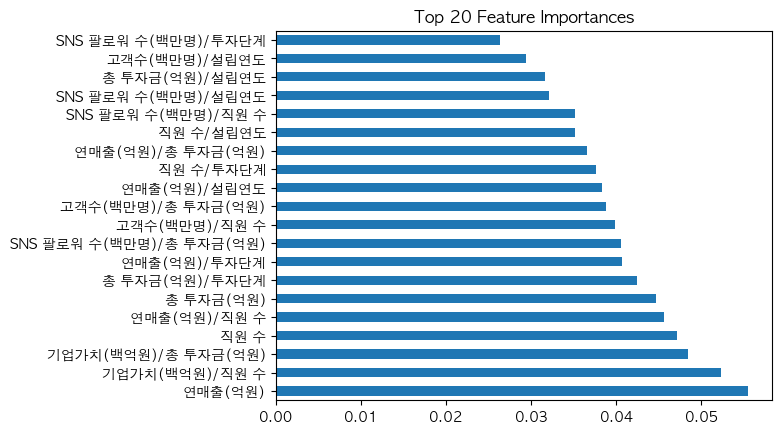

In [ ]:
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp.nlargest(20).plot(kind='barh')
plt.title("Top 20 Feature Importances")
plt.show()

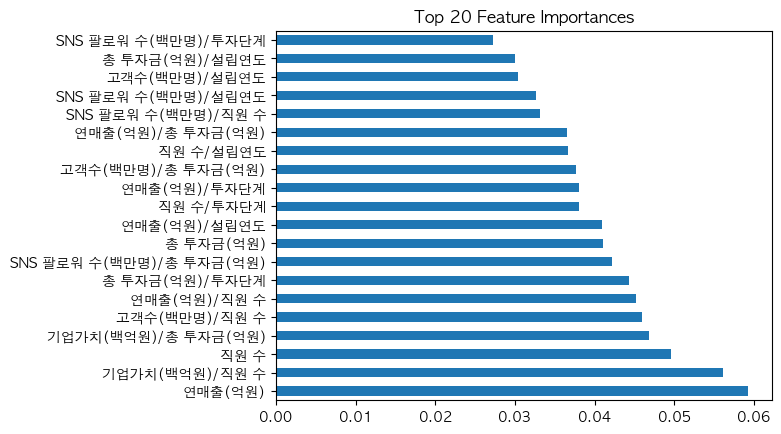

In [ ]:
feat_imp = pd.Series(model2.feature_importances_, index=X_train.columns)
feat_imp.nlargest(20).plot(kind='barh')
plt.title("Top 20 Feature Importances")
plt.show()

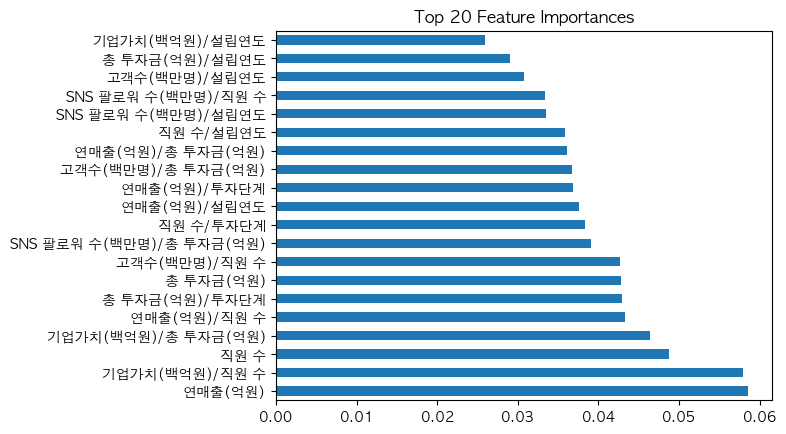

In [ ]:
feat_imp = pd.Series(model3.feature_importances_, index=X_train.columns)
feat_imp.nlargest(20).plot(kind='barh')
plt.title("Top 20 Feature Importances")
plt.show()

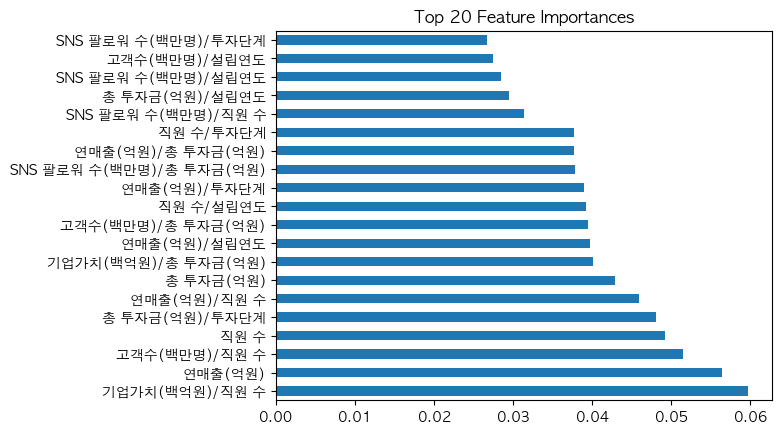

In [ ]:
feat_imp = pd.Series(model4.feature_importances_, index=X_train.columns)
feat_imp.nlargest(20).plot(kind='barh')
plt.title("Top 20 Feature Importances")
plt.show()

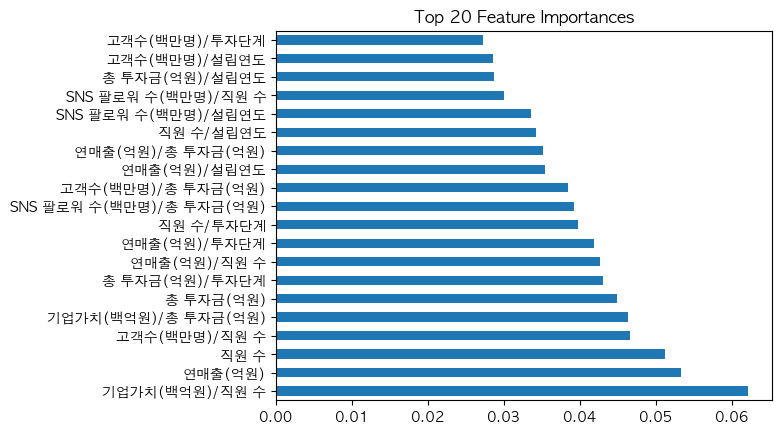

In [ ]:
feat_imp = pd.Series(model5.feature_importances_, index=X_train.columns)
feat_imp.nlargest(20).plot(kind='barh')
plt.title("Top 20 Feature Importances")
plt.show()

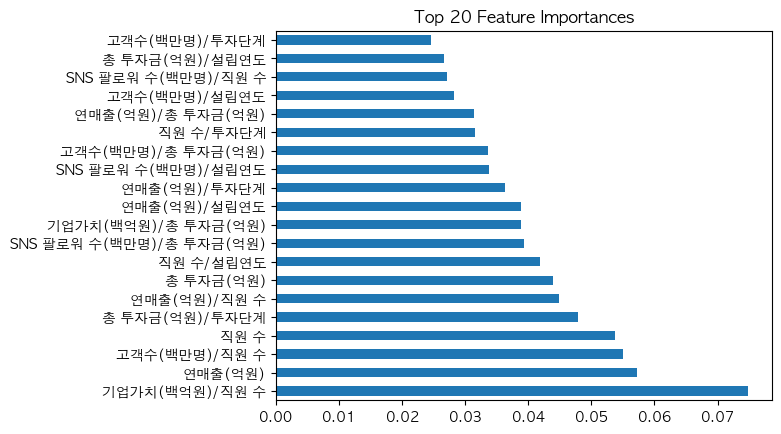

In [ ]:
feat_imp = pd.Series(model6.feature_importances_, index=X_train.columns)
feat_imp.nlargest(20).plot(kind='barh')
plt.title("Top 20 Feature Importances")
plt.show()

In [153]:
from xgboost import XGBRegressor
xgbmodel = XGBRegressor(
    objective='reg:logistic',
    n_estimators=1000,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)
xgbmodel.fit(X_train, y_train)

print("train score:",xgbmodel.score(X_train, y_train))
print("test score:",xgbmodel.score(X_test,y_test))


train score: 0.7311609291068234
test score: -0.17471111505293502


In [154]:
from sklearn.linear_model import LinearRegression

linmodel=LinearRegression()
linmodel.fit(X_train, y_train)
print("train score:",linmodel.score(X_train, y_train))
print("test score:",linmodel.score(X_test,y_test))

train score: 0.01956944436693464
test score: -0.024450751040737018


In [195]:
from sklearn.linear_model import LogisticRegression

logmodel = LogisticRegression()
logmodel.fit(X_train, y_train)

# 확률 예측 (시그모이드 결과)
print("train score:",linmodel.score(X_train, y_train))
print("test score:",linmodel.score(X_test,y_test))

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rfmodel = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,
    random_state=42
    )
rfmodel.fit(X_train, y_train)
print("train score:",rfmodel.score(X_train, y_train))
print("test score:",rfmodel.score(X_test,y_test))

train score: 0.8662313110950608
test score: -0.0046079015076874175


In [179]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [300, 500,700,1000],
    'max_depth': [3, 5, 7, None],
    'learning_rate': [0.001, 0.005, 0.01],
    'max_features': [None, 'sqrt', 'log2']
}

gbr = GradientBoostingRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',  # 회귀는 MSE로 평가
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best score:", -grid_search.best_score_)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'learning_rate': 0.001, 'max_depth': None, 'max_features': 'log2', 'n_estimators': 500}
Best score: 0.05801439713817031


In [189]:
md_test = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.005,
    max_depth=None,
    subsample=1,
    max_features='log2',
    random_state=42
)
md_test.fit(X_train, y_train)

print("train score:",md_test.score(X_train, y_train))
print("test score:",md_test.score(X_test,y_test))


train score: 0.6330421782738332
test score: 0.012127876445769181


In [192]:
from sklearn.metrics import r2_score
pred = md_test.predict(X_test)
pred = (pred - pred.mean()) / pred.std()
pred = 1 / (1 + np.exp(-1*pred))
r2_score(y_test,pred)

-0.5535603062317156

In [ ]:
from sklearn.metrics import r2_score
from sklearn.ensemble import GradientBoostingRegressor
import itertools


# 파라미터 그리드
param_grid = {
    'max_depth': [3, 5, 7, None],
    'n_estimators': [100, 300, 500, 700, 1000],
    'learning_rate': [0.001, 0.005, 0.01, 0.05, 0.1],
    'max_features': [None, 'sqrt', 'log2']
}

# 조합 생성
param_combinations = list(itertools.product(
    param_grid['max_depth'],
    param_grid['n_estimators'],
    param_grid['learning_rate'],
    param_grid['max_features']
))

best_score = -float('inf')
best_model = None
best_params = None

for depth, n_est, lr, mf in param_combinations:
    model = GradientBoostingRegressor(
        max_depth=depth, n_estimators=n_est, learning_rate=lr, max_features=mf, random_state=42
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = r2_score(y_test, preds)
    
    if score > best_score:
        best_score = score
        best_model = model
        best_params = {
            'max_depth': depth,
            'n_estimators': n_est,
            'learning_rate': lr,
            'max_features': mf
        }
        
print("R² on train set:",model.score(X_train,y_train))
print("Best R² on test set:", best_score)
print("Best parameters:", best_params)

'''결과
best = {
    'max_depth': None,
    'n_estimators': 100,
    'learning_rate': 0.005,
    'max_features': 'log2'
}'''


R² on train set: 0.9999999999999962
Best R² on test set: 0.012127876445769181
Best parameters: {'max_depth': None, 'n_estimators': 100, 'learning_rate': 0.005, 'max_features': 'log2'}


In [186]:
from sklearn.metrics import r2_score
from sklearn.ensemble import GradientBoostingRegressor
import itertools


# 파라미터 그리드
param_grid = {
    'n_estimators': [50,70,100,150,200,250,300,400,500],
    'learning_rate': [0.001, 0.002, 0.003, 0.005, 0.006, 0.007]
}

# 조합 생성
param_combinations = list(itertools.product(
    param_grid['n_estimators'],
    param_grid['learning_rate']
))

best_score = -float('inf')
best_model = None
best_params = None

for n_est, lr in param_combinations:
    model = GradientBoostingRegressor(
    n_estimators=n_est,
    learning_rate=lr,
    max_depth=None,
    subsample=1,
    max_features='log2',
    random_state=42
)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = r2_score(y_test, preds)
    
    if score > best_score:
        best_score = score
        best_model = model
        best_params = {
            'n_estimators': n_est,
            'learning_rate': lr,
        }
        
print("R² on train set:",model.score(X_train,y_train))
print("Best R² on test set:", best_score)
print("Best parameters:", best_params)

'''결과
best = {
    'n_estimators' : 100,
    'learning_rate' : 0.005
    }'''

KeyboardInterrupt: 

In [13]:
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import r2_score


# statsmodels는 상수항을 명시적으로 추가해야 함
X_train_const = sm.add_constant(X_train)

# GLM 모델: Binomial family + Logit link → 사실상 Beta regression처럼 동작
brmodel = sm.GLM(y_train, X_train_const, family=sm.families.Binomial(link=sm.families.links.logit()))
result = brmodel.fit()


X_test_const = sm.add_constant(X_test)
y_pred = result.predict(X_test_const)

r2_score(result.predict(X_train_const),y_train)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The logit link alias is deprecated. Use Logit instead. The logit link alias will be removed after the 0.15.0 release.
  warnings.warn(


-49.08675630081987